# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva - Marzo 2025
## Práctica: Regresión Lineal Simple con Scikit-Learn
---


## Datos del Estudiante

*   Apellidos y Nombre: Aguirre Higuera Pablo Alejandro
*   Matrícula: 263845

---

## Objetivo de aprendizaje
Al finalizar esta práctica, el estudiante será capaz de **aplicar la regresión lineal simple utilizando Scikit-Learn para modelar la relación entre dos variables numéricas**, verificar los principales supuestos del modelo (linealidad, normalidad de residuos y homocedasticidad), **interpretar los coeficientes del modelo**, calcular e interpretar la **correlación entre variables** y evaluar el desempeño del modelo mediante métricas como el MSE, RMSE y R².


Trabajarás con el archivo restaurantes.csv, que contiene dos columnas:

- `poblation`: población de la ciudad (variable independiente). Tiene valores decimales mayores que cero. Estos valores representan la población de la ciudad multiplicada por 10,000. Por ejemplo, 6.1101 significa que la población de esa ciudad es 61,101.

- `profit`: ganancia del restaurante en esa ciudad (variable dependiente). Tiene valores decimales, algunos negativos y otros positivos. Estos representan las ganancias mensuales promedio de su restaurante en cada ciudad, en unidades de $10,000. Por ejemplo, 17.592 representa 175,920 en ganancias mensuales promedio para esa ciudad. -2.6807 representa -26,807 en pérdidas mensuales promedio para esa ciudad.





## 🔧 Parte 1: Carga de datos y bibliotecas
1. Importa las bibliotecas necesarias.
2. Carga el archivo `restaurantes.csv`
3. Muestra las primeras filas del dataframe.
4. Describe estadísticamente el conjunto de datos.

In [1]:
# Escribe tu código aquí
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import scipy.stats as stats
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("restaurantes.csv")
df.head(5)


,poblation,profit
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


In [3]:
df.describe()

,poblation,profit
count,97.000000,97.000000
mean,8.159800,5.839135
std,3.869884,5.510262
min,5.026900,-2.680700
25%,5.707700,1.986900
50%,6.589400,4.562300
75%,8.578100,7.046700
max,22.203000,24.147000


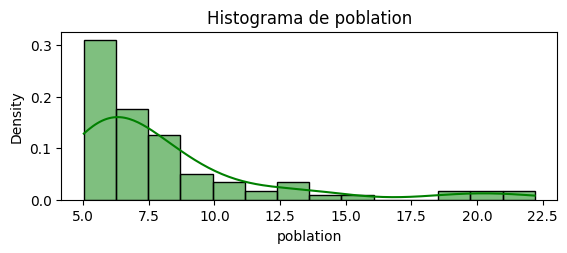

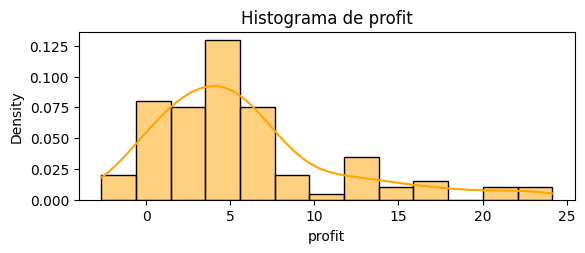

In [8]:
plt.subplot(2,1,1)
sns.histplot(df["poblation"], color="green", kde=True, stat="density")
plt.title("Histograma de poblation")
plt.show()

plt.subplot(2,1,2)
sns.histplot(df["profit"], color="orange", kde=True, stat="density")
plt.title("Histograma de profit")
plt.show()



Ambas variables presentan un sesgo a la derecha, especialmente la poblacion. Este sesgo indica que muy probablemente una prueba de normalidad rechace la hipótesis de que las variables son normales.

##  Parte 2: Análisis exploratorio y relación entre variables

### 2.1 Diagrama de Dispersión
1. Grafica un **diagrama de dispersión** entre `poblation` y `profit`
2. Responde:  
**¿La relación entre las variables parece lineal? ¿Por qué?**

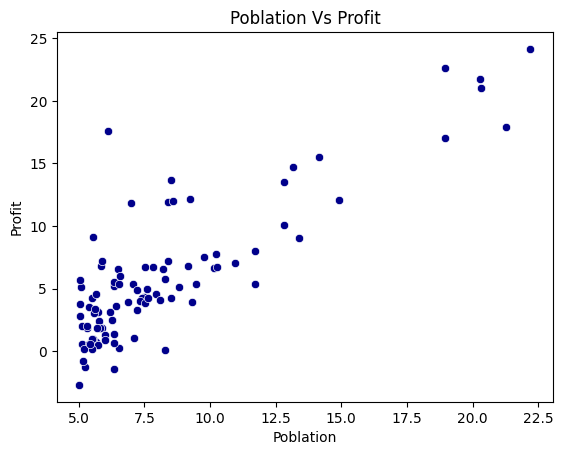

In [30]:
# Diagrama de dispersión
sns.scatterplot(x="poblation", y="profit", data=df, color="darkblue")
plt.title("Poblation Vs Profit")
plt.xlabel("Poblation")
plt.ylabel("Profit")
plt.show()

Aunque hay puntos al lado izquierdo de poblation atípicamente alejados de la recta naranja, se observa una fuerte tendencia de crecimiento lineal.

### 2.2: Cálculo e interpretación de la correlación
1. Calcula e imprime el **coeficiente de correlación de Pearson** entre `poblation` y `profit`
2. Interpreta el resultado:
- ¿Qué tan fuerte es la relación?
- ¿Es positiva o negativa?
- ¿Es coherente con el gráfico anterior?

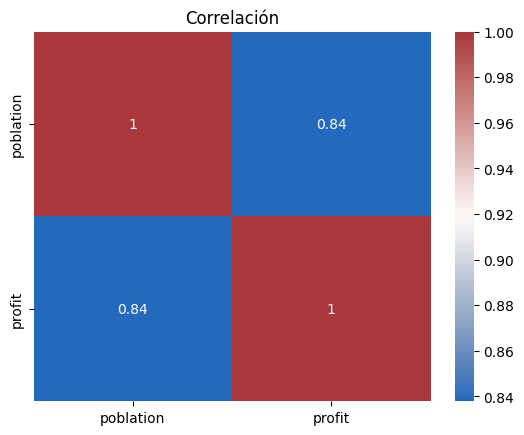

In [12]:
# Cálculo de correlación
matriz_corr = df.corr()
sns.heatmap(matriz_corr, annot=True, cbar=True, cmap="vlag")
plt.title("Correlación")
plt.show()

El índice de correlación es coherente con el gráfico de dispersión. Un valor de 0.84 indica una fuerte correlación positiva. Se concluye que un modelo lineal es un buen candidato para predecir profit en función de poblation.

## Parte 3: Construcción del modelo, coeficientes y visualización

###3.1 Construcción del modelo - obtención de los parámetros y coeficientes
1. Construye un modelo de regresión lineal simple usando las bibliotecas de Scikit-Learn
2. Imprime el intercepto y el coeficiente de la regresión (pendiente)
3. Interpreta el Intercepto: ¿Qué significa en términos del contexto del problema?
4. Interpreta el coeficiente de la regresión (pendiente) ¿Qué significa en términos del contexto del problema?

In [26]:
# Construcción del modelo  y Coeficientes del modelo
modelo = LinearRegression()
modelo.fit(df[["poblation"]], df["profit"])

coeficiente = np.round(modelo.coef_,3)
intercepto = np.round(modelo.intercept_,3)

ecuacion = f"Profit = {coeficiente} poblation {intercepto}"
print(ecuacion)

Profit = [1.193] poblation -3.896


En este caso, el intercepto no tiene un significado muy valioso; es lógico pensar que habrá perdidas si no hay habitantes. El modelo predice una pérdida de 38,960.00 dólares si no hay población. Respecto al alza de ganancias respecto a la población, se generan en promedio 11,930.00 dólares de utilidades por cada 10 mil habitantes.

### 3.2 Visualización del modelo
1. Grafica los puntos originales (poblation vs profit) y dibuja la línea de regresión ajustada.
2. Asegúrate de incluir leyenda y títulos.

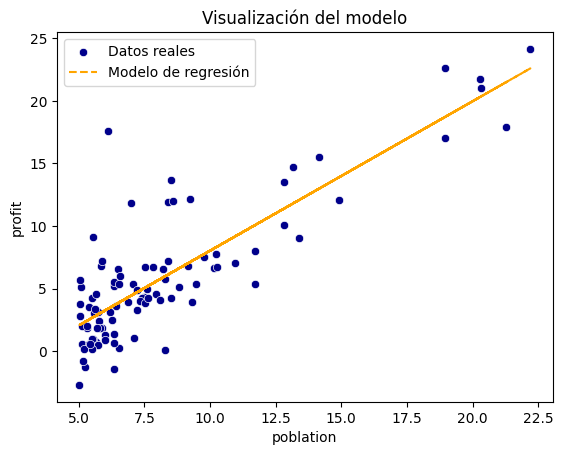

In [29]:
# Visualización del modelo ajustado
profit_pred = modelo.predict(df[["poblation"]])

sns.scatterplot(x="poblation", y="profit", data=df, color="darkblue", label="Datos reales")
plt.plot(df[["poblation"]], profit_pred, color="orange", linestyle="--", label="Modelo de regresión")
plt.title("Visualización del modelo")
plt.legend()
plt.show()

## Parte 4: Supuestos del modelo de regresión lineal

### 4.1. Normalidad de los residuos
1. Calcula los residuos (reales - predichos).
2. Grafica un **histograma con KDE** de los residuos.
3. Responde: ¿Los residuos siguen una distribución normal?

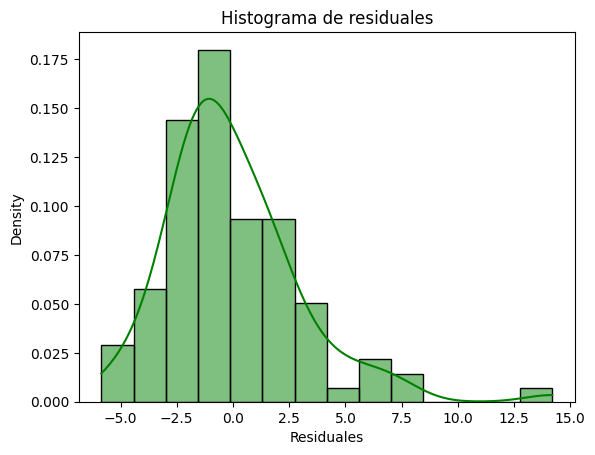

In [42]:
# Normalidad de los residuos
residuos = df["profit"] - profit_pred

sns.histplot(residuos, kde=True, color="green", stat="density")
plt.title("Histograma de residuales")
plt.xlabel("Residuales")
plt.show()


Ese dato atípico de casi 15 en los residuales sesga a la derecha la distribución. De no ser por eso, es razonable que pensar que se sigue una distribución normal.

### 4.2. Homocedasticidad
1. Grafica los residuos vs valores predichos.
2. ¿Los residuos están distribuidos aleatoriamente o muestran un patrón?

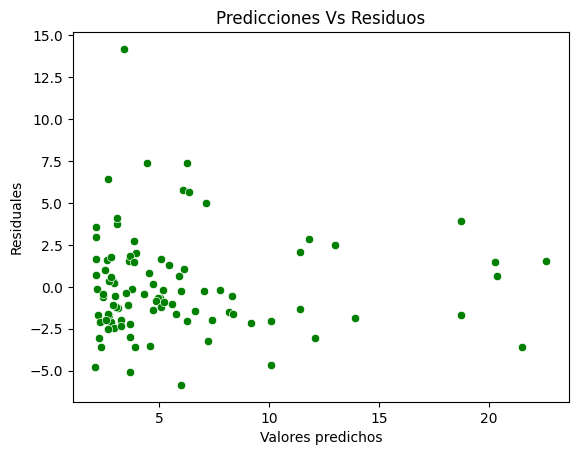

In [41]:
# Gráfico de residuos vs predichos
sns.scatterplot(x=profit_pred, y=residuos, color="green")
plt.title("Predicciones Vs Residuos")
plt.xlabel("Valores predichos")
plt.ylabel("Residuales")
plt.show()

Los residuos no muestran un patrón o forma particular. **Se cumple con el supuesto de homocedasticidad**.

### 4.3. Q-Q Plot para evaluar la normalidad
1. Grafica el Q-Q Plot:.
2. Interpreta el gráfico: a) Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal y b) Desviaciones sistemáticas indican asimetría o colas pesadas.

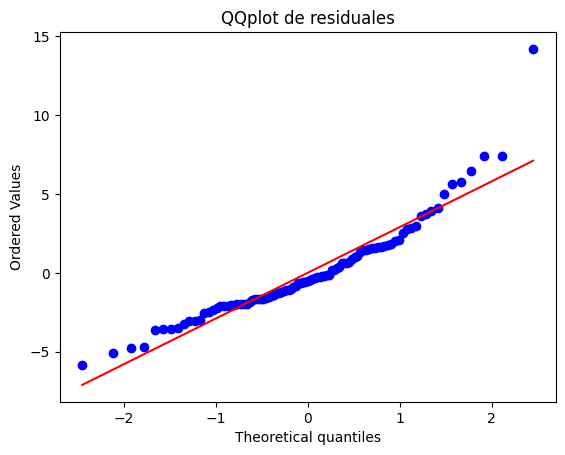

In [ ]:
# Q-Q Plot
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("QQplot de residuales")
plt.show()

De no ser por ese residual de casi 15, hay un ajuste aceptable con la normalidad. Vale la pena investigar ese residual altísimo de casi 15.

**Conclusión:** Tratando adecuadamente ese punto atípico, los residuales siguen una distribución normal.

## Parte 5: Evaluación del modelo
1. Calcula las métricas:
- MSE
- RMSE
- R²
2. Interpreta: ¿Qué nos dicen sobre el ajuste del modelo?

In [ ]:
# Evaluación del modelo
mse = mean_squared_error(df["profit"], profit_pred)  # Error cuadrático medio
rmse = np.sqrt(mse)  # Raíz del error cuadrático medio
r2 = r2_score(df["profit"], profit_pred)  # Coeficiente de determinación R^2

print(f"Error Cuadrático Medio (MSE): {mse:.3f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.3f}")
print(f"Coeficiente de Determinación (R²): {r2:.3f}")

Error Cuadrático Medio (MSE): 8.954
Raíz del Error Cuadrático Medio (RMSE): 2.992
Coeficiente de Determinación (R²): 0.702


En promedio, las predicciones del modelo se desvían 2.992 unidades de profit. Y se tiene que la población explica el 70.2% de la variación. Esto indica que el modelo se ajusta modedaramente bien.

## Parte 6: Conclusiones
Responde con tus propias palabras:
- ¿Qué tan útil consideras el modelo?
- ¿Qué limitaciones encuentras?
- ¿Crees que es necesario hacer un ajuste o estandarización a las variables dependientes o independientes?  Si crees que es necesario hacerlo realiza el ajuste.

Las predicciones que el modelo arroje no van a ser del todo fiables, pero sí es útil para saber que la población es una buena variable predictora... en complemento con otras (como el ingreso per cápita de la región, por ejemplo). 

Por el momento no es necesario hacer normalizaciones o estandarizaciones. De agregarse más variables al modelo, es posible que sea necesario ajustar la escala o distribución de las variables.